# ET7008 - Lab of Information Systems and Analytics

**Author:** Prof. Luca Cosmo  
**Institution:** Università Ca' Foscari (UNIVE)

---

# 1. Introduction to Clustering

Clustering is an **unsupervised learning** task that aims to group data points into clusters such that points in the same cluster are more similar to each other than to those in other clusters.

In this notebook, we will explore three main families of clustering algorithms:
1. **Partitioning Methods** (K-Means)
2. **Hierarchical Methods** (Agglomerative Clustering)
3. **Density-Based Methods** (DBSCAN)

We will analyze their behavior, hyper-parameters, and performance using both synthetic and real-world datasets.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_blobs, make_moons
from scipy.cluster.hierarchy import dendrogram, linkage

%matplotlib inline
sns.set(style="whitegrid")

## 2. K-Means Clustering

### 2.1 Theory
K-Means is a partitioning algorithm that divides $N$ observations into $K$ clusters. It minimizes the **Within-Cluster Sum of Squares (WCSS)**, also known as **Inertia**:
$$ J =
yum_{i=1}^{K} \sum_{x \in C_i} ||x - \mu_i||^2 $$
where $\mu_i$ is the centroid of cluster $C_i$.

**Algorithm Steps:**
1. Initialize $K$ centroids randomly.
2. **Assignment**: Assign each point to the nearest centroid.
3. **Update**: Recompute centroids as the mean of assigned points.
4. Repeat until convergence.

### 2.2 Toy Example: K-Means Behavior
Let's see how K-Means handles simple blobs and how the choice of $K$ affects the result.

/tmp/ipykernel_5813/1046652774.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')


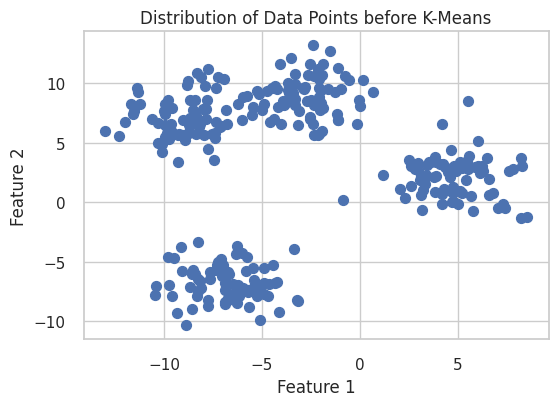

In [ ]:
# Generate synthetic data
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.7, random_state=42)

#display the input points
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')
plt.title('Distribution of Data Points before K-Means')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### 2.3 K-Means with Default Parameters and Analysis

Let's apply K-Means with `n_clusters=4` (since our synthetic data was generated with 4 centers) and analyze its parameters and outputs.

### 2.4 Analysis of K-Means Parameters, Outputs, and Optimized Parameters

When we ran K-Means, we configured several key parameters:

*   **`n_clusters=4`**: This is arguably the most critical parameter, defining the number of clusters K that the algorithm should attempt to find. In our case, we chose 4 because our synthetic data was explicitly generated with 4 distinct centers.
*   **`random_state=42`**: This parameter ensures reproducibility. K-Means initialization often involves random centroid placement, and setting a `random_state` makes sure that the random process is the same every time you run the code, yielding consistent results.
*   **`n_init=10`**: This parameter specifies the number of times the K-Means algorithm will be run with different centroid seeds. The final result will be the best output of `n_init` consecutive runs in terms of inertia. This helps mitigate the issue of K-Means converging to suboptimal local minima due to poor initial centroid placement.

**Key Outputs:**

*   **`y_pred` (Cluster Labels)**: This array contains the cluster assignment for each data point in `X`. Each point is assigned an integer label corresponding to its cluster (e.g., 0, 1, 2, 3).
*   **`kmeans_default.cluster_centers_` (Optimized Parameters)**: These are the final positions of the cluster centroids after the K-Means algorithm has converged. They represent the means of all points assigned to each respective cluster. These centroids are the **optimized parameters** that the algorithm finds to minimize the WCSS.
*   **`kmeans_default.inertia_` (WCSS)**: Also known as the Within-Cluster Sum of Squares, this value represents the sum of squared distances of samples to their closest cluster center. It's a measure of how internally coherent clusters are, and K-Means aims to minimize this value. A lower inertia generally indicates better clustering, though it tends to decrease with increasing K.

In [ ]:
# Initialize and fit K-Means with n_clusters=4
kmeans_default = KMeans(n_clusters=4, random_state=42, n_init=10) # Using random_state for reproducibility and n_init=10 as recommended default
y_pred = kmeans_default.fit_predict(X) # Predict cluster labels for each data point

y_pred

array([3, 3, 0, 1, 3, 1, 2, 1, 0, 2, 0, 2, 0, 0, 3, 0, 3, 2, 0, 0, 2, 0,
       1, 3, 0, 3, 3, 1, 1, 2, 0, 2, 3, 2, 3, 0, 3, 1, 3, 1, 2, 0, 3, 1,
       0, 0, 3, 2, 3, 2, 1, 3, 1, 0, 1, 2, 3, 2, 2, 0, 3, 2, 2, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 3, 2, 0, 3, 1, 1, 0, 1, 0, 0, 3, 0, 1, 3, 3, 2,
       2, 2, 3, 0, 3, 0, 0, 3, 1, 0, 3, 3, 2, 2, 2, 0, 0, 0, 0, 0, 1, 3,
       2, 0, 0, 0, 0, 2, 3, 1, 3, 1, 1, 1, 0, 3, 1, 3, 3, 0, 3, 1, 2, 0,
       0, 0, 0, 2, 2, 3, 0, 1, 0, 2, 1, 0, 2, 2, 2, 2, 1, 0, 0, 0, 2, 1,
       0, 2, 1, 3, 3, 2, 3, 3, 1, 3, 2, 3, 1, 0, 0, 0, 0, 0, 1, 2, 2, 1,
       1, 2, 2, 1, 3, 0, 3, 2, 2, 3, 1, 0, 2, 2, 1, 1, 1, 3, 2, 1, 1, 2,
       2, 3, 0, 0, 1, 2, 0, 1, 1, 3, 1, 0, 0, 1, 1, 2, 3, 1, 3, 3, 0, 3,
       3, 1, 3, 1, 2, 2, 3, 0, 2, 2, 2, 3, 0, 1, 2, 1, 3, 2, 3, 3, 3, 1,
       1, 2, 3, 1, 1, 1, 3, 1, 3, 1, 3, 2, 1, 3, 2, 0, 3, 0, 2, 0, 3, 0,
       1, 2, 1, 2, 2, 0, 0, 1, 2, 2, 3, 3, 1, 0, 0, 2, 2, 2, 2, 1, 3, 2,
       1, 2, 2, 1, 0, 1, 2, 0, 3, 0, 2, 0, 3, 3], d

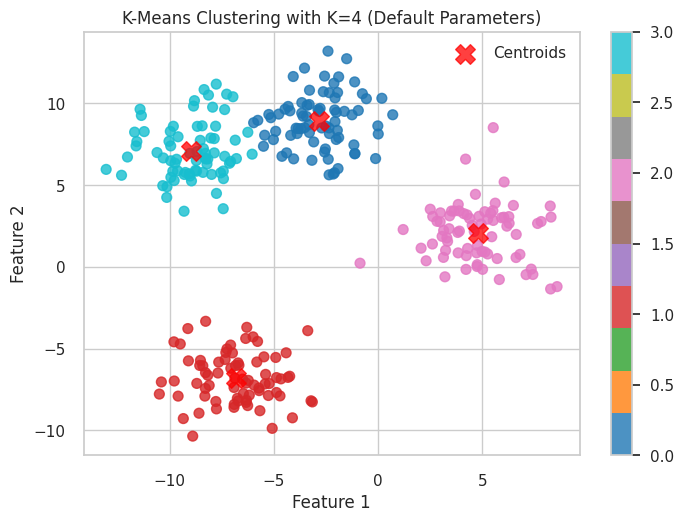


Optimized Cluster Centers (Optimized Parameters):
[[-2.81420312  8.91593458]
 [-6.79925945 -6.79570101]
 [ 4.77303314  2.08983571]
 [-8.95841487  7.08780612]]

WCSS (Inertia):
1596.8534080082334


In [ ]:

# Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=50, cmap='tab10', alpha=0.8) # Plot data points, colored by cluster
plt.colorbar()
centers = kmeans_default.cluster_centers_ # Get the final cluster centroids
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids') # Plot centroids
plt.title('K-Means Clustering with K=4 (Default Parameters)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

print("\nOptimized Cluster Centers (Optimized Parameters):")
print(centers) # Print cluster centroids
print("\nWCSS (Inertia):")
print(kmeans_default.inertia_) # Print Within-Cluster Sum of Squares (WCSS)

### 2.5 K-Means Behavior with Different K Values
Let's visualize how K-Means behaves when we try to fit it with different numbers of clusters ($K$) on our synthetic data. This will help us understand the impact of choosing an inappropriate $K$ value.

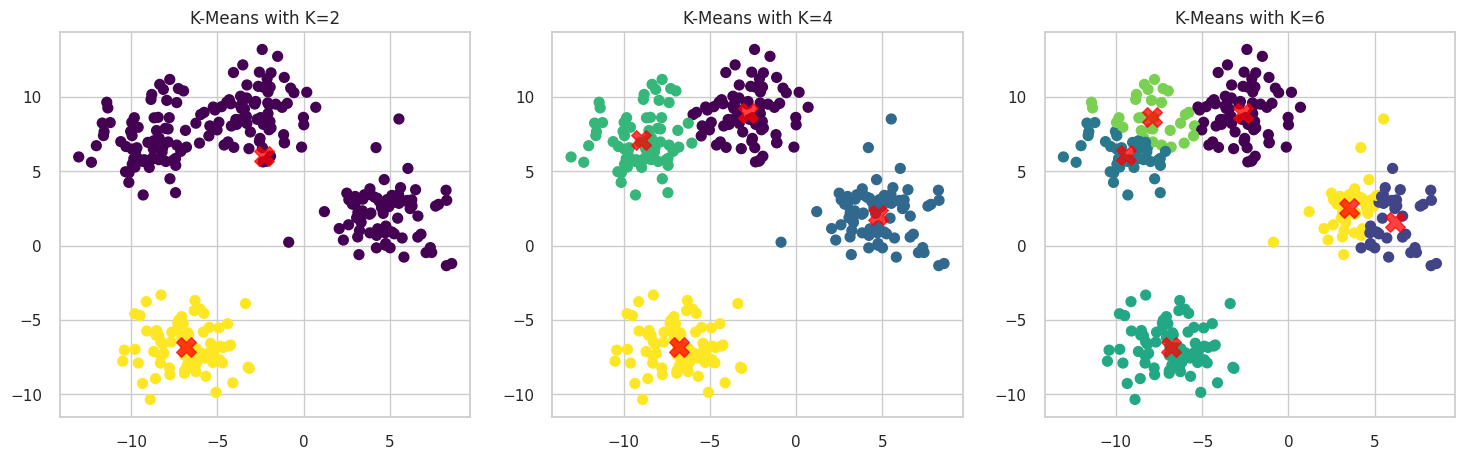

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Create a figure and a set of subplots for visualization

# Loop through different values of K (number of clusters)
for i, k in enumerate([2, 4, 6]):
    # Initialize KMeans with the current K value
    # 'init='random'' for random centroid initialization, 'n_init=10' to run 10 times and choose the best result
    # 'random_state' for reproducibility
    kmeans = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    # Fit KMeans to the data and predict cluster labels for each data point
    y_kmeans = kmeans.fit_predict(X)

    # Plot the data points, colored by their assigned cluster
    axes[i].scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
    # Extract the optimized centroids from the fitted KMeans model
    centers = kmeans.cluster_centers_ #after fitting, we can extract the optimized centroids
    # Plot the cluster centroids on top of the data points
    axes[i].scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
    axes[i].set_title(f'K-Means with K={k}')

plt.show() # Display the plots

### 2.6 Finding the Optimal K
We use the **Elbow Method** (Inertia) and the **Silhouette Score** to find the best $K$.

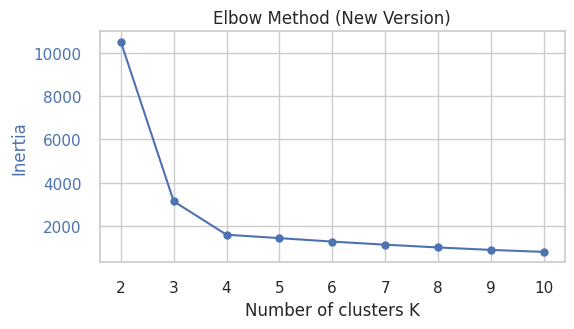

In [ ]:
inertia_new = [] # Stores inertia values for different K
K_range_new = range(2, 11) # Range of K values to test for Elbow Method

for k in K_range_new:
    # Initialize KMeans with current K, run 10 times to find the best centroids, ensuring reproducibility
    km_new = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_new = km_new.fit_predict(X)
    inertia_new.append(km_new.inertia_) # Collect WCSS for current K

fig_new, ax1_new = plt.subplots(figsize=(6, 3))

# Plot inertia values against the number of clusters K
ax1_new.plot(K_range_new, inertia_new, 'bo-', label='Inertia (WCSS)')
ax1_new.set_xlabel('Number of clusters K')
ax1_new.set_ylabel('Inertia', color='b')
ax1_new.tick_params('y', colors='b')

plt.title('Elbow Method (New Version)')
plt.show()


#### 2.6.1 Silhouette Score
The **silhouette coefficient** for a single sample measures how similar that sample is to its own cluster (cohesion) compared to other clusters (separation). It ranges from -1 to 1.

- **1**: Indicates the sample is well-matched to its own cluster and poorly matched to neighboring clusters.
- **0**: Indicates the sample is on or very close to the decision boundary between two neighboring clusters.
- **-1**: Indicates the sample might be assigned to the wrong cluster.

The **average silhouette score** (or just silhouette score) for a set of samples is the mean of the silhouette coefficients for all samples. It provides an overall measure of how well samples are clustered.

These concepts are implemented in scikit-learn:
- The `silhouette_score` function calculates the **average silhouette coefficient** for all samples.
- The `silhouette_samples` function calculates the **individual silhouette coefficient** for each sample, which is then used to visualize the silhouette plot for each cluster.

Average Silhouette Score for K=4 (using silhouette_score function): 0.4712


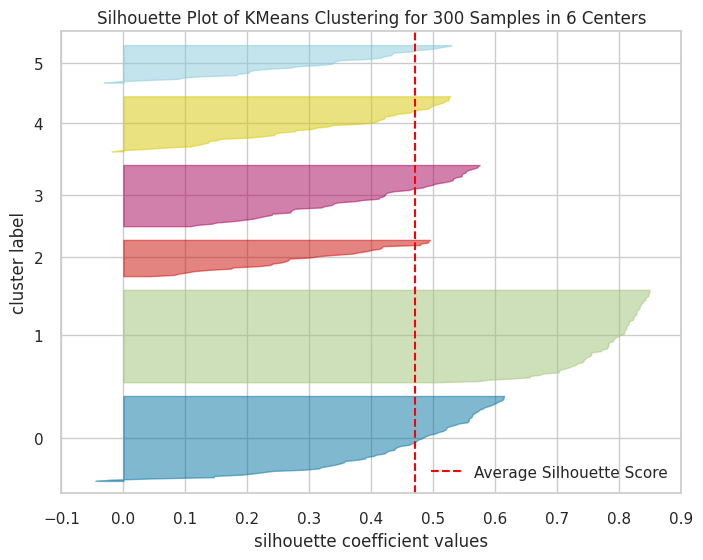

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 300 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.metrics import silhouette_score

# Initialize the K-Means model
km = KMeans(n_clusters=6, init='k-means++', n_init=10, max_iter=100, random_state=42)

# Fit KMeans and get labels
labels = km.fit_predict(X)

# Compute and print the silhouette score using the function directly
sil_score = silhouette_score(X, labels)
print(f"Average Silhouette Score for K=4 (using silhouette_score function): {sil_score:.4f}")

silhouette_samples(X, labels)

# Create a SilhouetteVisualizer instance
fig, ax = plt.subplots(figsize=(8, 6))
visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax)

# Fit the data to the visualizer (this also calculates internal silhouette score for plotting)
visualizer.fit(X)

# Set title and labels
visualizer.ax.set_title('Silhouette Plot with Yellowbrick for K=4')
visualizer.ax.set_xlabel('Silhouette coefficient values')
visualizer.ax.set_ylabel('Cluster label')

# Display the plot
visualizer.show()

#### 2.6.2 Silhouette Plots for Different K Values

Let's visualize the silhouette plots for K=2, K=4, and K=6 to understand how the choice of K impacts cluster cohesion and separation.

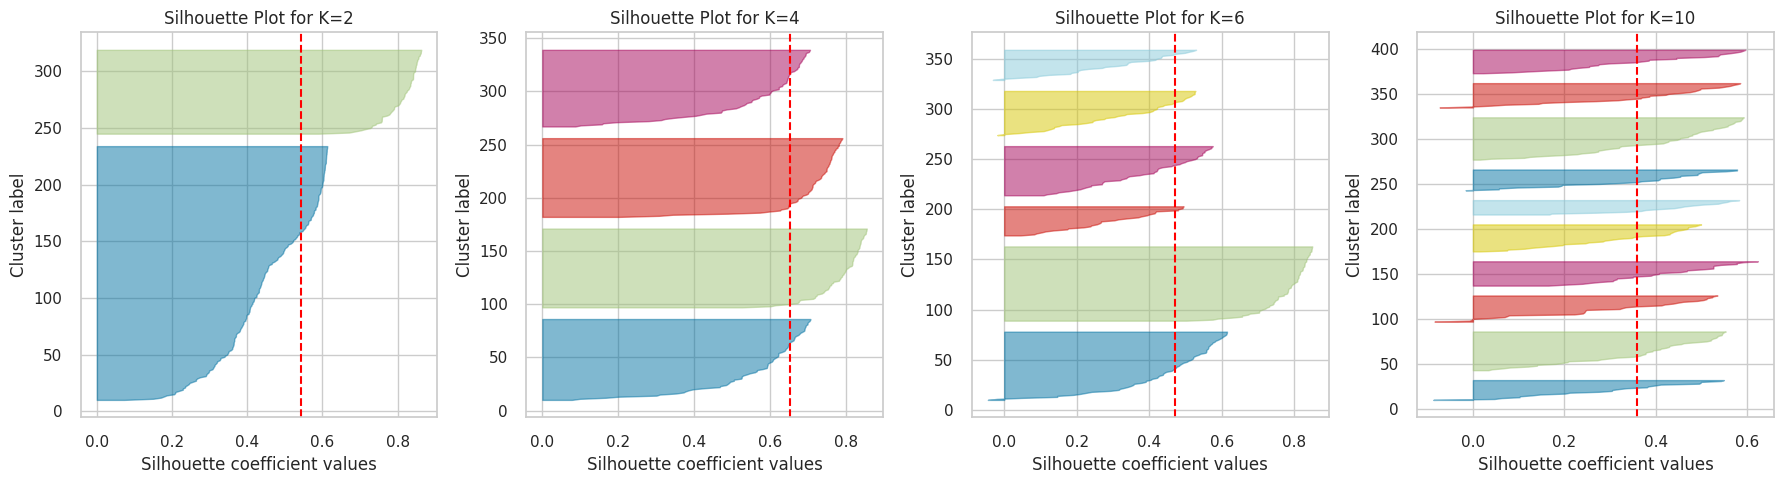

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, k in enumerate([2, 4, 6, 10]):
    # Initialize KMeans with the current K value
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=42)

    # Create a SilhouetteVisualizer instance for the current subplot
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=axes[i])

    # Fit the data to the visualizer
    visualizer.fit(X)

    # Set title and labels for the current subplot
    visualizer.ax.set_title(f'Silhouette Plot for K={k}')
    visualizer.ax.set_xlabel('Silhouette coefficient values')
    visualizer.ax.set_ylabel('Cluster label')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

#### 2.6.3 Combined Elbow Method and Silhouette Score Plot

Let's visualize both the Inertia (Elbow Method) and the average Silhouette Score on a single plot to identify the optimal number of clusters more effectively.

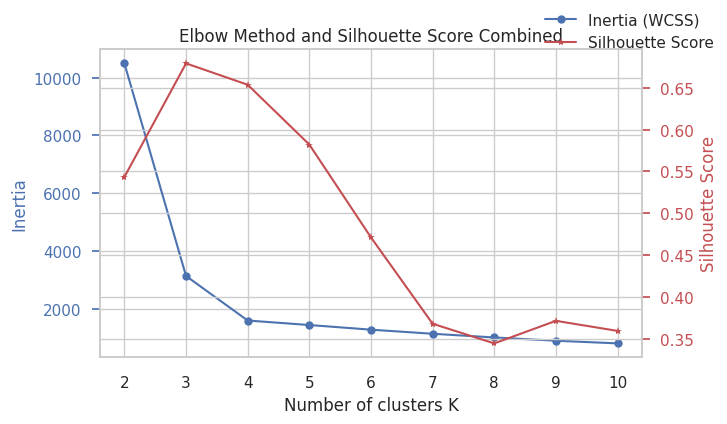

In [ ]:
inertia_combined = []
silhouette_scores_combined = []
K_range_combined = range(2, 11)

for k in K_range_combined:
    # Initialize KMeans with current K, run 10 times to find the best centroids, ensuring reproducibility
    km_combined = KMeans(n_clusters=k, n_init=10, random_state=42)
    # Fit KMeans to the data and predict cluster labels
    labels_combined = km_combined.fit_predict(X)
    # Collect WCSS (Inertia) for current K
    inertia_combined.append(km_combined.inertia_)
    # Collect silhouette score for current K
    silhouette_scores_combined.append(silhouette_score(X, labels_combined))

# Create a figure and a primary y-axis for inertia
fig_combined, ax1_combined = plt.subplots(figsize=(7, 4))

# Plot inertia values against the number of clusters K
ax1_combined.plot(K_range_combined, inertia_combined, 'bo-', label='Inertia (WCSS)')
ax1_combined.set_xlabel('Number of clusters K')
ax1_combined.set_ylabel('Inertia', color='b')
ax1_combined.tick_params('y', colors='b')

# Create a second y-axis that shares the same x-axis for silhouette scores
ax2_combined = ax1_combined.twinx()
ax2_combined.plot(K_range_combined, silhouette_scores_combined, 'r*-', label='Silhouette Score')
ax2_combined.set_ylabel('Silhouette Score', color='r')
ax2_combined.tick_params('y', colors='r')

# Add title and simplified legend placement
plt.title('Elbow Method and Silhouette Score Combined')
fig_combined.legend(loc='upper right')

plt.show()

## 3. Hierarchical Clustering

### 3.1 Theory
Hierarchical clustering builds a tree of clusters (Dendrogram). **Agglomerative** is a bottom-up approach: each point starts as its own cluster, and pairs are merged based on a **Linkage Criterion**:
- **Single**: Minimum distance between points in clusters.
- **Complete**: Maximum distance between points in clusters.
- **Average**: Average distance between all pairs.
- **Ward**: Minimizes the variance of clusters being merged.

/tmp/ipykernel_5813/270686830.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_moons[:, 0], X_moons[:, 1], s=50, cmap='viridis')


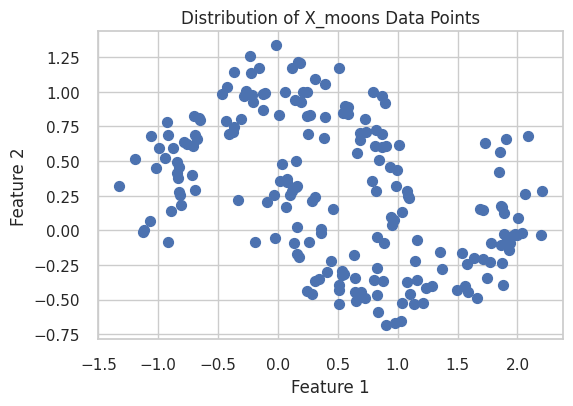

In [ ]:
from sklearn.cluster import AgglomerativeClustering
# Generate non-spherical data
X_moons, _ = make_moons(n_samples=200, noise=0.14, random_state=42)

#show moons points
plt.figure(figsize=(6, 4))
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=50, cmap='viridis')
plt.title('Distribution of X_moons Data Points')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### 3.2 K-Means vs. Hierarchical Clustering on Non-Spherical Data (Moons)

Let's compare the performance of K-Means and Hierarchical Clustering (specifically Agglomerative Clustering with single linkage) on the `X_moons` dataset. This dataset is a classic example where K-Means often struggles due to its assumption of spherical clusters, while hierarchical methods with appropriate linkage can perform well.

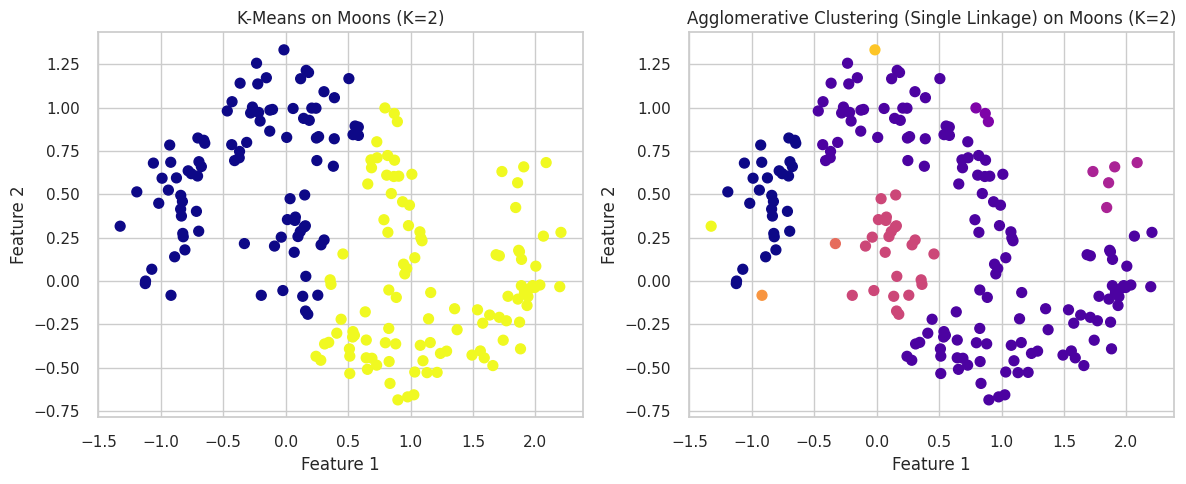

Observation: K-Means struggles with the non-convex shape of the moons dataset, often splitting one 'moon' into two clusters. Single Linkage, however, is able to correctly identify the two moon shapes due to its ability to form elongated clusters based on the closest points.


In [ ]:
# Initialize K-Means with 2 clusters
kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_kmeans_moons = kmeans_moons.fit_predict(X_moons)

# Initialize Agglomerative Clustering with 2 clusters and 'single' linkage
# agg_single_moons = AgglomerativeClustering(n_clusters=2, linkage='single')
agg_single_moons = AgglomerativeClustering(n_clusters=None, distance_threshold=0.2, linkage='single')
labels_agg_single_moons = agg_single_moons.fit_predict(X_moons)

# Plot the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K-Means Plot
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_kmeans_moons, s=50, cmap='plasma')
axes[0].set_title('K-Means on Moons (K=2)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# Hierarchical Clustering (Single Linkage) Plot
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_agg_single_moons, s=50, cmap='plasma')
axes[1].set_title('Agglomerative Clustering (Single Linkage) on Moons (K=2)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print("Observation: K-Means struggles with the non-convex shape of the moons dataset, often splitting one 'moon' into two clusters. Single Linkage, however, is able to correctly identify the two moon shapes due to its ability to form elongated clusters based on the closest points.")

In [ ]:
set(labels_agg_single_moons)

{np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8)}

### 3.3 Hierarchical Clustering on Non-Spherical Data (Moons) with Different Linkage Methods

We'll now apply Agglomerative Clustering to the `X_moons` dataset using various linkage methods. This will highlight how each method forms clusters on a dataset that is challenging for algorithms like K-Means due to its non-globular shape.

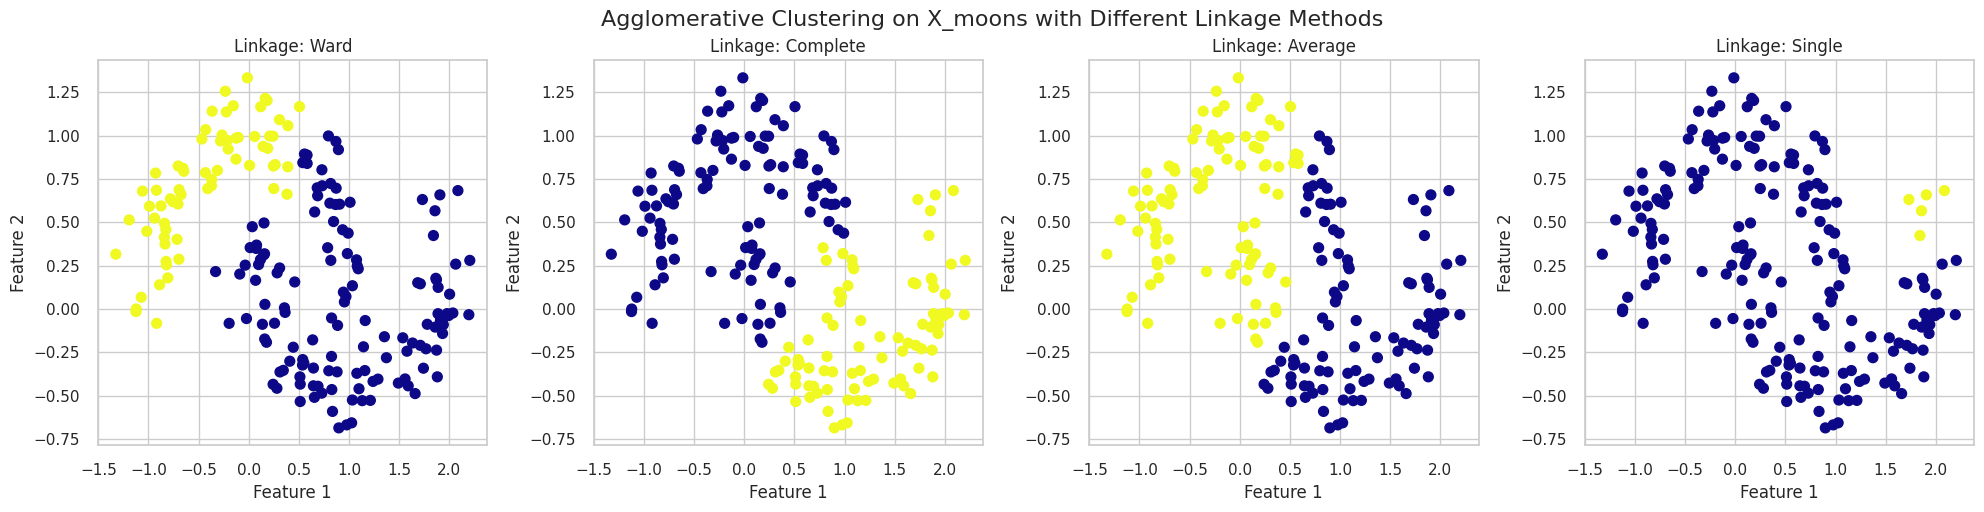

In [ ]:
linkage_methods = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(1, len(linkage_methods), figsize=(20, 5))

for i, method in enumerate(linkage_methods):
    # Apply Agglomerative Clustering with 2 clusters (as expected for moons) and the current linkage method
    agg_clustering = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels = agg_clustering.fit_predict(X_moons)

    # Plot the results
    axes[i].scatter(X_moons[:, 0], X_moons[:, 1], c=labels, s=50, cmap='plasma')
    axes[i].set_title(f'Linkage: {method.capitalize()}')
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')

plt.tight_layout()
plt.suptitle('Agglomerative Clustering on X_moons with Different Linkage Methods', y=1.02, fontsize=16)
plt.show()


### 3.4 Exercise: Comparing K-Means and Hierarchical Clustering on Different Datasets

**Objective:** Understand the strengths and weaknesses of K-Means and Hierarchical Clustering (with different linkage methods) by applying them to various synthetic datasets.

1.  **Generate Data:** Use `make_blobs` and `make_moons` to create two distinct datasets. For `make_blobs`, use `n_samples=300`, `centers=3`, and `random_state=42`. For `make_moons`, use `n_samples=300`, `noise=0.05`, and `random_state=42`.

2.  **K-Means Clustering:**
    *   Apply K-Means with `n_clusters=3` to the 'blobs' dataset. Plot the results.
    *   Apply K-Means with `n_clusters=2` to the 'moons' dataset. Plot the results.
    *   **Discuss:** What do you observe? Why does K-Means perform differently on these two datasets?

3.  **Hierarchical Clustering (Agglomerative):**
    *   Apply Agglomerative Clustering to the 'blobs' dataset using `n_clusters=3` and each of the following `linkage` methods: 'ward', 'complete', 'average', 'single'. Plot the results for each linkage method.
    *   Apply Agglomerative Clustering to the 'moons' dataset using `n_clusters=2` and each of the following `linkage` methods: 'ward', 'complete', 'average', 'single'. Plot the results for each linkage method.
    *   **Discuss:** How do the different linkage methods affect the clustering results for both 'blobs' and 'moons'? Which method performs best for each dataset and why?

4.  **Overall Comparison:** Summarize your findings on when to prefer K-Means versus Hierarchical Clustering, and when to choose a specific linkage method.

## 4. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

### 4.1 Theory
DBSCAN groups points that are closely packed together. It requires two parameters:
- **eps ($\epsilon$)**: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
- **min_samples**: The number of samples in a neighborhood for a point to be considered as a core point.

**Advantages:**
- Can find clusters of arbitrary shape.
- Robust to outliers (noise).

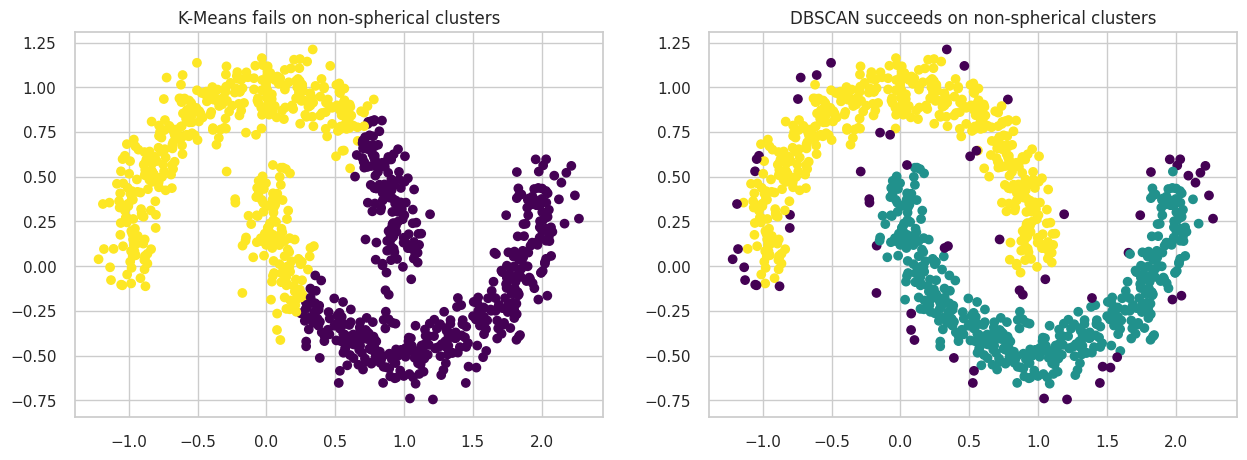

In [ ]:
# Generate non-spherical data
X_moons, _ = make_moons(n_samples=1000, noise=0.1, random_state=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

km = KMeans(n_clusters=2, n_init=10, random_state=42)
ax1.scatter(X_moons[:, 0], X_moons[:, 1], c=km.fit_predict(X_moons), cmap='viridis')
ax1.set_title("K-Means fails on non-spherical clusters")

db = DBSCAN(eps=0.1, min_samples=10)
# db = DBSCAN(eps=0.2, min_samples=4)
ax2.scatter(X_moons[:, 0], X_moons[:, 1], c=db.fit_predict(X_moons), cmap='viridis')
ax2.set_title("DBSCAN succeeds on non-spherical clusters")

plt.show()

### 4.2 Parameter Tuning for DBSCAN: Estimating `eps`

One of the challenges with DBSCAN is selecting appropriate values for `eps` and `min_samples`. While `min_samples` is often set based on the dimensionality of the data (e.g., `2 * dimensionality`), `eps` is more challenging.

AThe **k-distance plot** is a common heuristic used to estimate the optimal `eps` value. For each point, we calculate the distance to its $k$-th nearest neighbor (where $k$ is typically `min_samples`). We then plot these k-distances in ascending order. The "elbow" point in this plot, where the curve sharply changes direction, is often a good candidate for `eps`.

In [ ]:
# distances
# indices

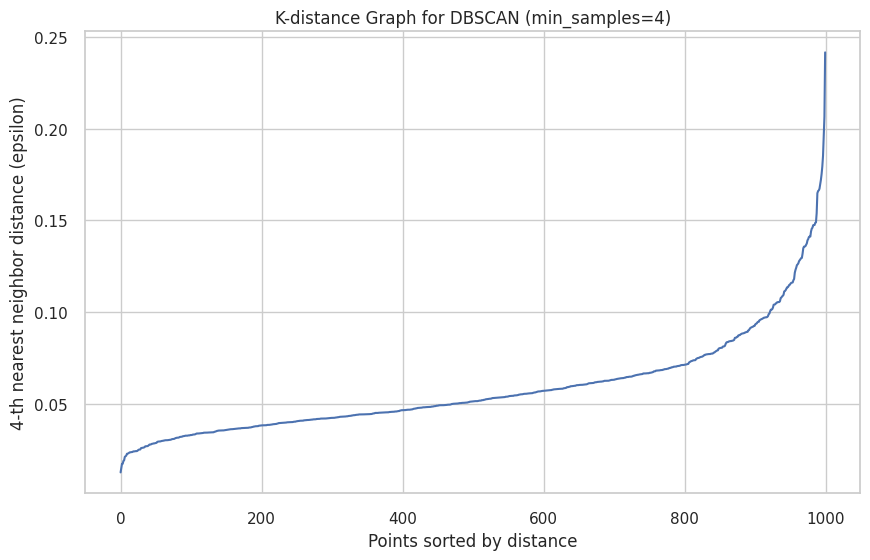

Look for an 'elbow' in the plot to estimate `eps`. A sharp change suggests a good candidate for `eps`.


In [ ]:
from sklearn.neighbors import NearestNeighbors

# Let's use the X_moons dataset for demonstration
# min_samples is often set to 2 * dimensionality of the data
min_samples = 4

# Calculate the distance to the k-th nearest neighbor for each point
# k = min_samples - 1 because NearestNeighbors includes the point itself in the count for `k`
neighbors = NearestNeighbors(n_neighbors=min_samples+1)
neighbors_fit = neighbors.fit(X_moons)
distances, indices = neighbors_fit.kneighbors(X_moons)

# Sort distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, -1], axis=0) # Take the last column (k-th distance)

# Plot the k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples}-th nearest neighbor distance (epsilon)')
plt.title(f'K-distance Graph for DBSCAN (min_samples={min_samples})')
plt.grid(True)
plt.show()

print(f"Look for an 'elbow' in the plot to estimate `eps`. A sharp change suggests a good candidate for `eps`.")

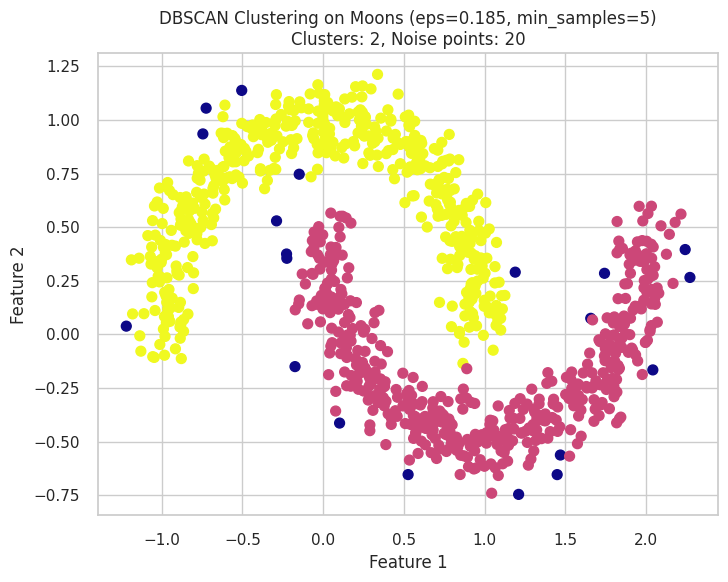

In [ ]:
# Apply DBSCAN with the estimated epsilon
dbscan_moons = DBSCAN(eps=0.1, min_samples=4) # Using eps=0.185 as chosen by the user and min_samples=5
labels_dbscan_moons = dbscan_moons.fit_predict(X_moons)

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels_dbscan_moons)) - (1 if -1 in labels_dbscan_moons else 0)
n_noise_ = list(labels_dbscan_moons).count(-1)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_dbscan_moons, s=50, cmap='plasma')
plt.title(f'DBSCAN Clustering on Moons (eps=0.185, min_samples=5)\nClusters: {n_clusters_}, Noise points: {n_noise_}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

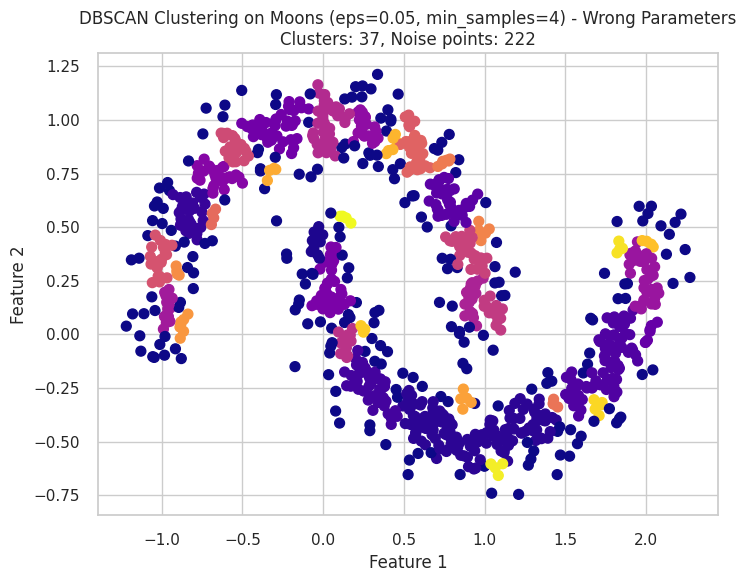

Observation: With a very small 'eps', many points are classified as noise (-1), and the clusters are fragmented or entirely missed.


In [ ]:
# Apply DBSCAN with intentionally 'wrong' parameters
# For example, a very small eps might result in too many noise points or fragmented clusters
# A very large eps might merge too many distinct clusters
dbscan_moons_wrong = DBSCAN(eps=0.05, min_samples=4) # Using a much smaller eps than ideal
labels_dbscan_moons_wrong = dbscan_moons_wrong.fit_predict(X_moons)

# Number of clusters in labels, ignoring noise if present.
n_clusters_wrong = len(set(labels_dbscan_moons_wrong)) - (1 if -1 in labels_dbscan_moons_wrong else 0)
n_noise_wrong = list(labels_dbscan_moons_wrong).count(-1)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_dbscan_moons_wrong, s=50, cmap='plasma')
plt.title(f'DBSCAN Clustering on Moons (eps=0.05, min_samples=4) - Wrong Parameters\nClusters: {n_clusters_wrong}, Noise points: {n_noise_wrong}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

print("Observation: With a very small 'eps', many points are classified as noise (-1), and the clusters are fragmented or entirely missed.")

### 4.3 Exercise: Advanced Comparison of Clustering Algorithms

**Objective:** Deepen your understanding of Agglomerative Clustering (with various linkage methods) and DBSCAN by applying them to synthetic datasets and comparing their behaviors.

1.  **Generate Data:** Use `make_blobs` and `make_moons` to create two distinct datasets:
    *   For `make_blobs`, use `n_samples=300`, `centers=3`, and `random_state=42`.
    *   For `make_moons`, use `n_samples=300`, `noise=0.05`, and `random_state=42`.

2.  **Agglomerative Clustering (Linkage Comparison):**
    *   Apply Agglomerative Clustering to the **'blobs' dataset** using `n_clusters=3` and each of the following `linkage` methods: 'ward', 'complete', 'average', 'single'. Plot the results for each linkage method.
    *   Apply Agglomerative Clustering to the **'moons' dataset** using `n_clusters=2` and each of the following `linkage` methods: 'ward', 'complete', 'average', 'single'. Plot the results for each linkage method.
    *   **Discuss:** How do the different linkage methods affect the clustering results for both 'blobs' and 'moons'? Which method performs best for each dataset and why?

3.  **DBSCAN Application and Parameter Exploration:**
    *   Apply DBSCAN to the **'blobs' dataset**. Experiment with different `eps` and `min_samples` values. Plot the results. How does DBSCAN perform on spherical clusters compared to K-Means and Agglomerative Clustering? (Hint: You might need to adjust parameters carefully to find meaningful clusters).
    *   Apply DBSCAN to the **'moons' dataset**. Again, experiment with `eps` and `min_samples`. Plot the results. How does DBSCAN handle the non-convex shape of the 'moons' dataset? Compare its performance with single-linkage hierarchical clustering.
    *   **Discuss:** What are the advantages and disadvantages of DBSCAN in these scenarios? When would you prefer DBSCAN over K-Means or Agglomerative Clustering?

4.  **Overall Summary:** Summarize your findings regarding the strengths and weaknesses of K-Means, Agglomerative Clustering (with different linkages), and DBSCAN across these synthetic datasets. Provide guidance on when to choose each algorithm.

## 5. Dataset: Mall Customer Segmentation

Let's explore the 'Mall Customer Segmentation Data', a popular didactic dataset for clustering. It contains demographic and spending information for mall customers, perfect for demonstrating how clustering can be used for customer segmentation.

In [ ]:
!wget https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/8bd6144a87988213693754baaa13fb204933282d/Mall_Customers.csv

--2026-04-29 09:59:58--  https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/8bd6144a87988213693754baaa13fb204933282d/Mall_Customers.csv
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3780 (3.7K) [text/plain]
Saving to: ‘Mall_Customers.csv’

Mall_Customers.csv  100%[===================>]   3.69K  --.-KB/s    in 0s      

2026-04-29 09:59:58 (38.5 MB/s) - ‘Mall_Customers.csv’ saved [3780/3780]



In [ ]:
mall_df = pd.read_csv('Mall_Customers.csv')

print(f"Dataset shape: {mall_df.shape}")
display(mall_df.head())

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
print("--- DataFrame Info ---")
mall_df.info()

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
print("\n--- Descriptive Statistics ---")
display(mall_df.describe())


--- Descriptive Statistics ---


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### 5.1 Data Preprocessing for Mall Customer Segmentation

Before applying clustering algorithms, we need to preprocess the data. This involves:
1.  **Dropping irrelevant columns**: 'CustomerID' is just an identifier.
2.  **Encoding categorical features**: 'Gender' needs to be converted into numerical format.
3.  **Scaling numerical features**: Clustering algorithms are sensitive to the scale of the features, so we'll standardize 'Age', 'Annual Income (k$)', and 'Spending Score (1-100)'.

In [ ]:
# Drop CustomerID as it's just an identifier
mall_df_processed = mall_df.drop('CustomerID', axis=1)

# Encode Gender column (Male=1, Female=0)
mall_df_processed['Gender'] = mall_df_processed['Gender'].map({'Male': 1, 'Female': 0})

print("DataFrame after dropping CustomerID and encoding Gender:")
display(mall_df_processed.head())

DataFrame after dropping CustomerID and encoding Gender:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


#### 5.1.1 Scaling Numerical Features

We will now scale the numerical features ('Age', 'Annual Income (k$)', 'Spending Score (1-100)') using `StandardScaler`. This ensures that all features contribute equally to the distance calculations in clustering algorithms.

In [ ]:
scaler = StandardScaler()

# Select the numerical columns to scale
numerical_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
mall_df_processed[numerical_cols] = scaler.fit_transform(mall_df_processed[numerical_cols])

print("DataFrame after scaling numerical features:")
display(mall_df_processed.head())

DataFrame after scaling numerical features:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,-1.424569,-1.738999,-0.434801
1,1,-1.281035,-1.738999,1.195704
2,0,-1.352802,-1.700830,-1.715913
3,0,-1.137502,-1.700830,1.040418
4,0,-0.563369,-1.662660,-0.395980


#### 5.1.2 Correlation Analysis

Let's examine the correlation between the features to understand their relationships.

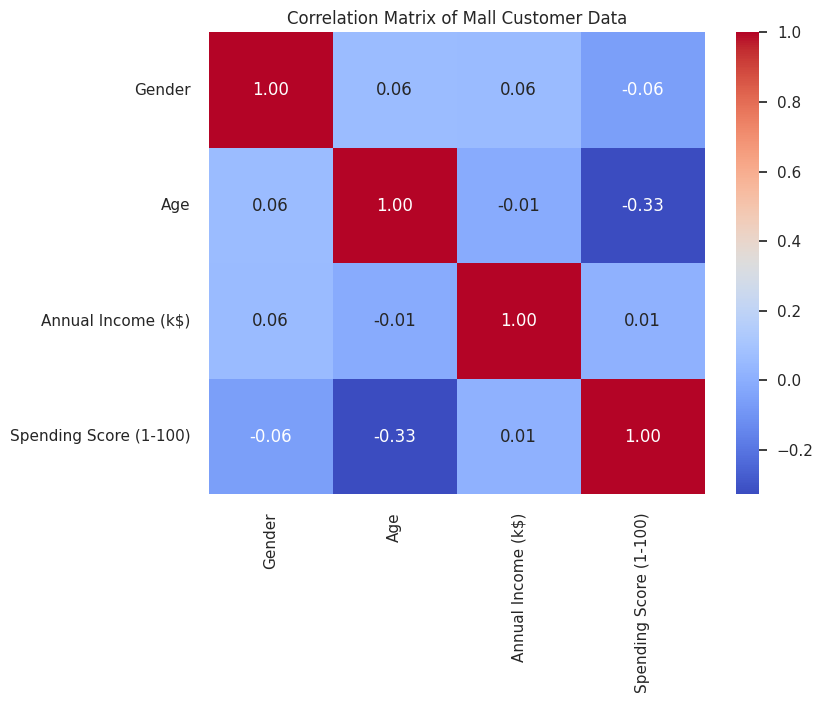

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(mall_df_processed.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Mall Customer Data')
plt.show()

### 5.2 Determining the Optimal Number of Clusters for Mall Customer Data

To find the optimal number of clusters (K) for our mall customer segmentation, we will use two common methods:
1.  **Elbow Method (Inertia)**: We plot the Within-Cluster Sum of Squares (WCSS) against the number of clusters and look for an 'elbow' point where the rate of decrease significantly slows down.
2.  **Silhouette Score**: This metric measures how similar an object is to its own cluster compared to other clusters. A higher silhouette score indicates better-defined clusters.

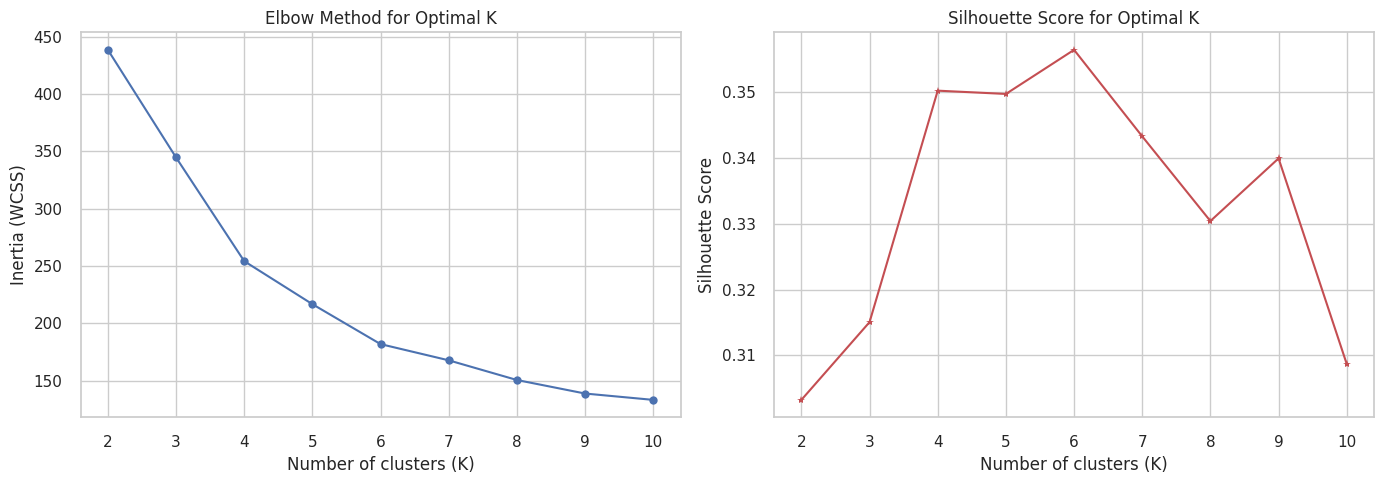

In [ ]:
inertia = []
silhouette_scores = []
K_range = range(2, 11) # Test K from 2 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(mall_df_processed)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(mall_df_processed, labels))

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method plot
ax1.plot(K_range, inertia, 'bo-')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method for Optimal K')
ax1.grid(True)

# Silhouette Score plot
ax2.plot(K_range, silhouette_scores, 'r*-')
ax2.set_xlabel('Number of clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Optimal K')
ax2.grid(True)

plt.tight_layout()
plt.show()

### 5.3 Applying K-Means Clustering with Optimal K

Based on our analysis (hypothetically choosing K=6 from the Elbow and Silhouette plots), we will now apply K-Means clustering with 6 clusters to segment our customers. We will then visualize these clusters and analyze their characteristics.

In [ ]:
# Apply K-Means with 5 clusters
X_for_clustering = mall_df_processed.values
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
mall_df_processed['Cluster'] = kmeans_final.fit_predict(X_for_clustering)

print("Cluster assignments added to the DataFrame.")
display(mall_df_processed.head())

Cluster assignments added to the DataFrame.


,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,-1.424569,-1.738999,-0.434801,0
1,1,-1.281035,-1.738999,1.195704,0
2,0,-1.352802,-1.700830,-1.715913,3
3,0,-1.137502,-1.700830,1.040418,0
4,0,-0.563369,-1.662660,-0.395980,3


Silhouette Score for Agglomerative Clustering with K=6: 0.4893


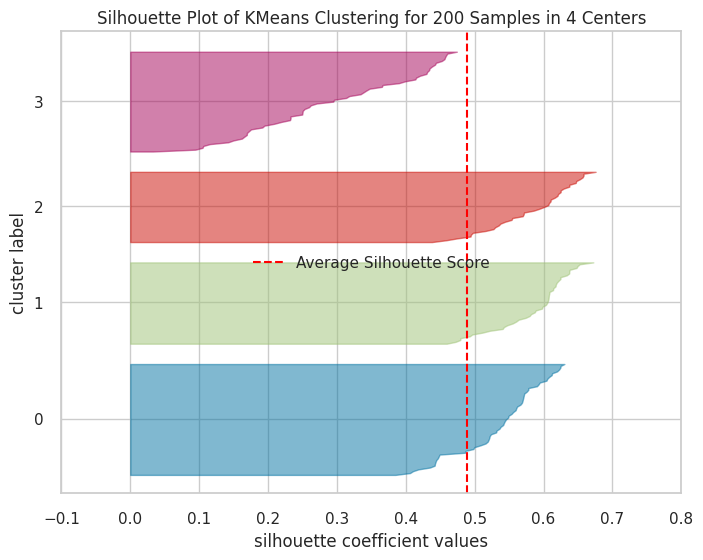

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 200 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score for Agglomerative Clustering
silhouette_agg = silhouette_score(X_for_clustering, mall_df_processed['Cluster'])
print(f"Silhouette Score for Agglomerative Clustering with K=6: {silhouette_agg:.4f}")

# Create a SilhouetteVisualizer instance (pass estimator=None and the labels separately)
fig, ax = plt.subplots(figsize=(8, 6))
visualizer = SilhouetteVisualizer(estimator=kmeans_final, colors='yellowbrick', ax=ax) # Pass estimator=None here

# Fit the data to the visualizer
visualizer.fit(X_for_clustering)

# Set title and labels
visualizer.ax.set_title('Silhouette Plot for Agglomerative Clustering (K=4)')
visualizer.ax.set_xlabel('Silhouette coefficient values')
visualizer.ax.set_ylabel('Cluster label')

# Display the plot
visualizer.show()


### 5.4 Visualizing the Clusters

Let's visualize the clusters using scatter plots, focusing on key features like 'Annual Income (k$)', 'Spending Score (1-100)', and 'Age'. This will help us understand the characteristics of each customer segment.

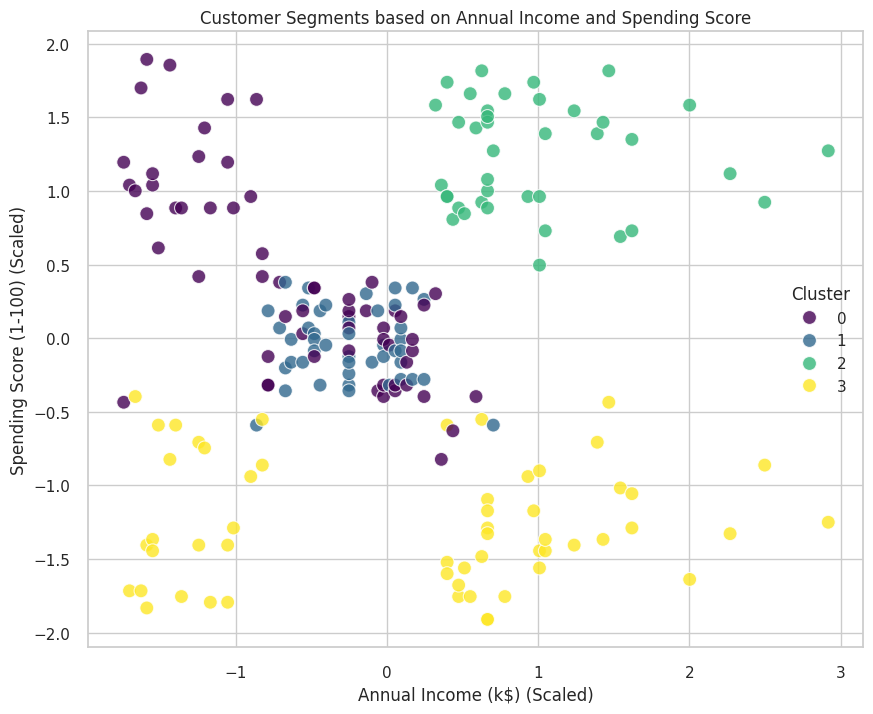

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=mall_df_processed, palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$) (Scaled)')
plt.ylabel('Spending Score (1-100) (Scaled)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

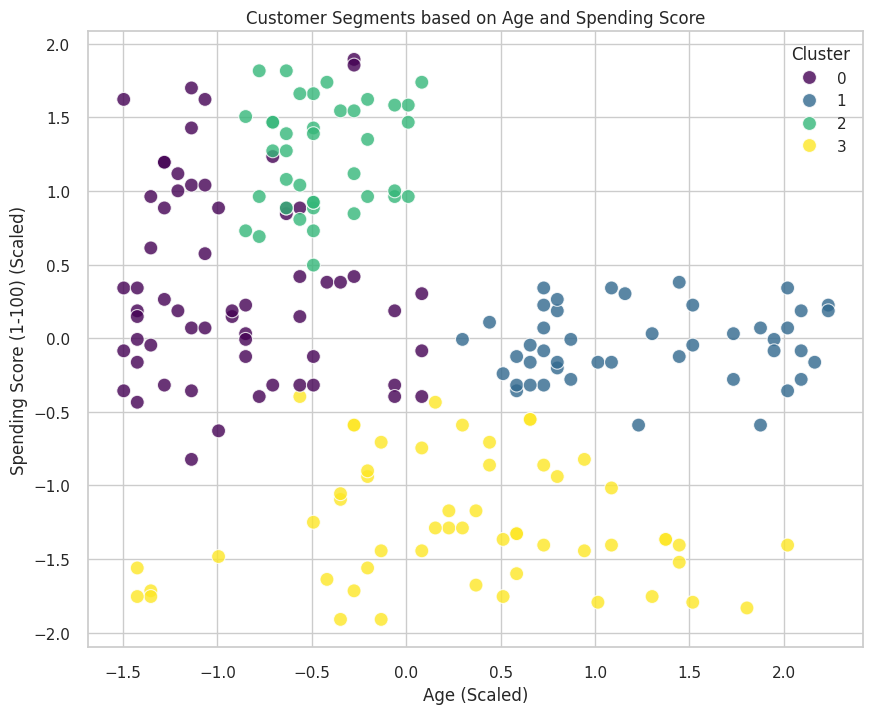

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='Cluster', data=mall_df_processed, palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments based on Age and Spending Score')
plt.xlabel('Age (Scaled)')
plt.ylabel('Spending Score (1-100) (Scaled)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### 5.5 Interpreting the Customer Segments

Now that we have visualized the clusters, let's look at the average characteristics of each cluster to define our customer segments. We can use the original (unscaled) values for better interpretability.

In [ ]:
# Add the cluster labels back to the original (unscaled) DataFrame for easier interpretation
mall_df_original_with_clusters = mall_df.copy()
mall_df_original_with_clusters['Cluster'] = mall_df_processed['Cluster']

# Group by cluster and calculate the mean and standard deviation of each feature
# Using a dictionary of lists for agg will create a MultiIndex for the columns.
cluster_summary = mall_df_original_with_clusters.groupby('Cluster').agg({
    'Age': ['mean', 'std'],
    'Annual Income (k$)': ['mean', 'std'],
    'Spending Score (1-100)': ['mean', 'std'],
    # For Gender, we want a single ratio, so we'll create a named aggregation within a list
    'Gender': [('Male_Ratio', lambda x: (x == 'Male').sum() / len(x))]
}).reset_index()

display(cluster_summary)

print("\nBased on this summary, we can define the characteristics of each customer segment.")

Cluster        Age            Annual Income (k$)             \
                mean        std               mean        std   
0       0  26.245902   6.461826          44.819672  17.826486   
1       1  56.333333   8.453079          54.266667   8.975725   
2       2  32.692308   3.728650          86.538462  16.312485   
3       3  42.890909  11.247506          64.745455  33.437182   

  Spending Score (1-100)                Gender  
                    mean        std Male_Ratio  
0              59.868852  17.212859   0.377049  
1              49.066667   6.300794   0.422222  
2              82.128205   9.364489   0.461538  
3              17.763636  10.940857   0.509091


Based on this summary, we can define the characteristics of each customer segment.


### 5.6 Applying Agglomerative Clustering to Mall Customer Data

Now, let's explore Agglomerative Clustering on our preprocessed Mall Customer data. We will start by visualizing a dendrogram to understand the hierarchical relationships and aid in choosing the optimal number of clusters.

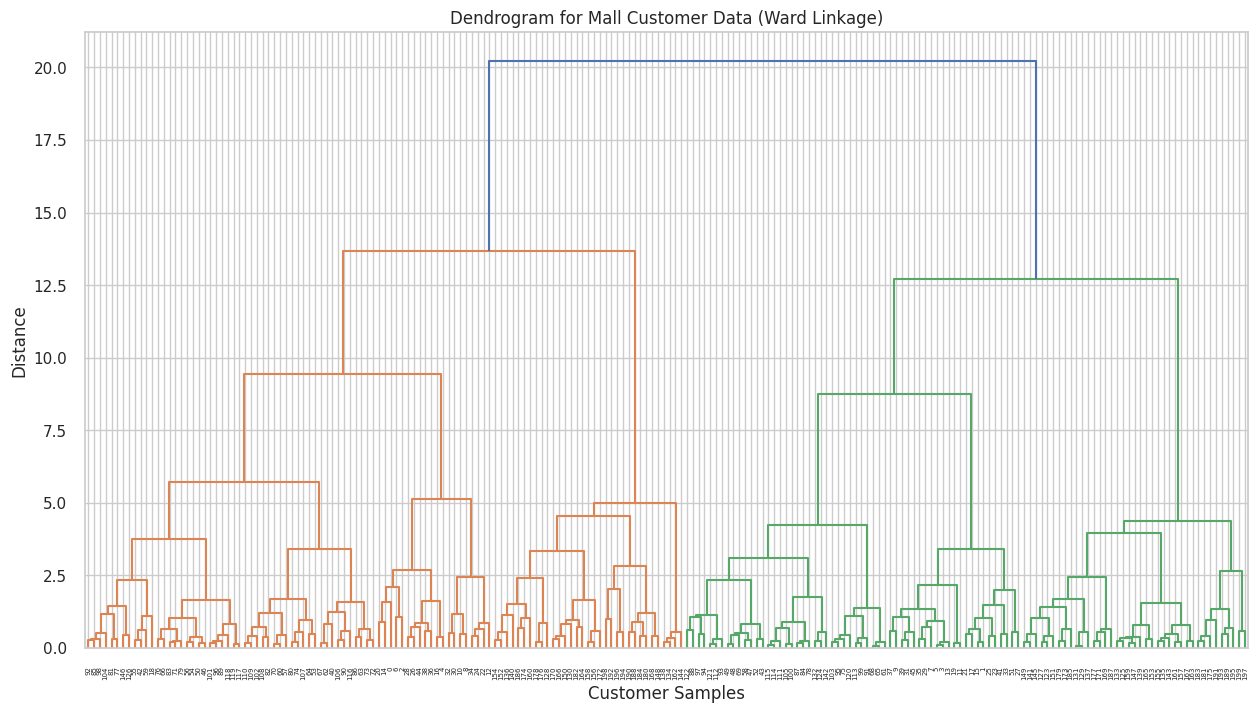

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

X_for_clustering = mall_df_processed.drop('Cluster', axis=1)

# Generate the linkage matrix
linked = linkage(X_for_clustering, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram for Mall Customer Data (Ward Linkage)')
plt.xlabel('Customer Samples')
plt.ylabel('Distance')
plt.show()

#### 5.6.1 Interpreting the Dendrogram

The dendrogram visually represents the merging of clusters. To determine the optimal number of clusters, we look for the largest vertical distance that does not intersect any horizontal lines. Cutting the dendrogram at this point will give us the clusters. Based on the dendrogram, we can observe distinct groupings and potentially confirm or adjust our choice of 4 clusters.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Clustering with 4 clusters (for comparison with K-Means)
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward') # 'ward' is generally a good default
mall_df_processed['Agg_Cluster'] = agg_clustering.fit_predict(X_for_clustering)

print("Agglomerative Cluster assignments added to the DataFrame.")
display(mall_df_processed.head())

Agglomerative Cluster assignments added to the DataFrame.


,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Agg_Cluster
0,1,-1.424569,-1.738999,-0.434801,0,0
1,1,-1.281035,-1.738999,1.195704,0,1
2,0,-1.352802,-1.700830,-1.715913,3,0
3,0,-1.137502,-1.700830,1.040418,0,1
4,0,-0.563369,-1.662660,-0.395980,3,0


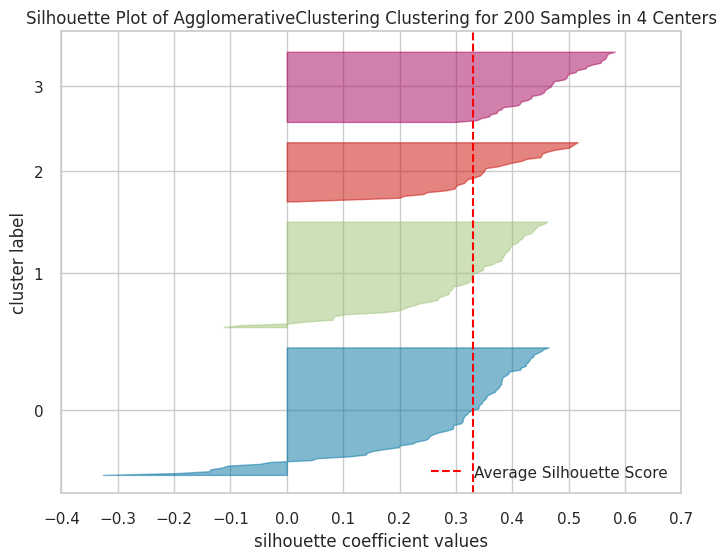

<Axes: title={'center': 'Silhouette Plot of AgglomerativeClustering Clustering for 200 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

# Initialize AgglomerativeClustering with the determined optimal number of clusters
agg_clustering_sil = AgglomerativeClustering(n_clusters=4, linkage='ward') # Ensure n_clusters matches the previous application

# Get the cluster labels from AgglomerativeClustering
agg_labels = agg_clustering_sil.fit_predict(X_for_clustering)
agg_clustering_sil.predict = lambda x=None: agg_labels #hack to use SilhouetteScore for visualization

# Create a SilhouetteVisualizer instance (pass estimator=None and the labels separately)
fig, ax = plt.subplots(figsize=(8, 6))
visualizer = SilhouetteVisualizer(estimator=agg_clustering_sil, colors='yellowbrick', ax=ax, is_fitted=False) # Pass estimator=None here

# Fit the data and the computed labels to the visualizer
visualizer.fit(X_for_clustering) # Pass labels directly to fit()

# Set title and labels
visualizer.ax.set_title('Silhouette Plot for Agglomerative Clustering (K=5)')
visualizer.ax.set_xlabel('Silhouette coefficient values')
visualizer.ax.set_ylabel('Cluster label')

# Display the plot
visualizer.show()

### 5.7 Visualizing Agglomerative Clusters

Let's visualize the clusters generated by Agglomerative Clustering, focusing on the same key features as before.

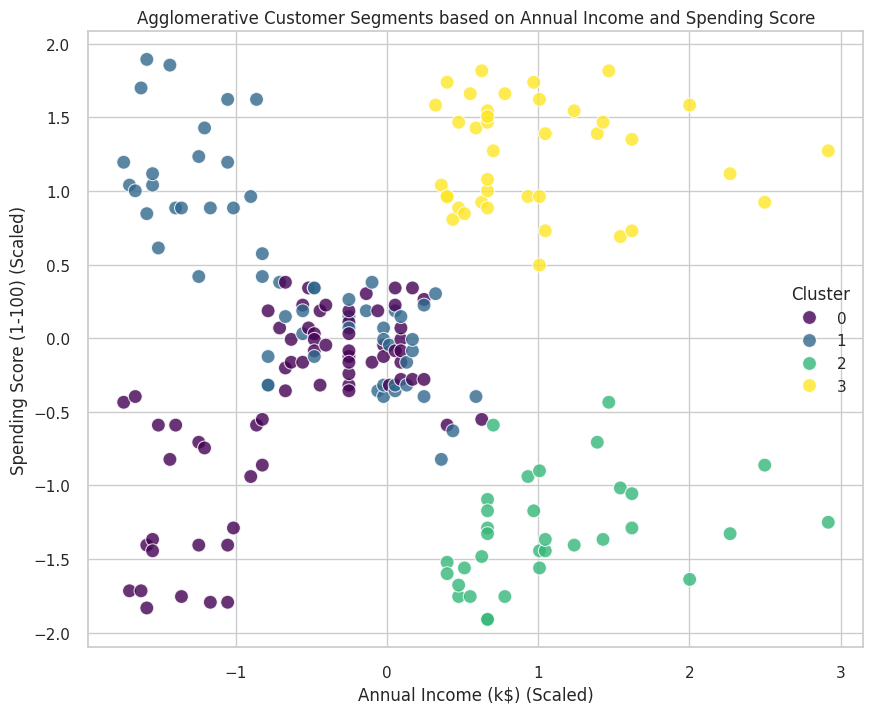

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Agg_Cluster', data=mall_df_processed, palette='viridis', s=100, alpha=0.8)
plt.title('Agglomerative Customer Segments based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$) (Scaled)')
plt.ylabel('Spending Score (1-100) (Scaled)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

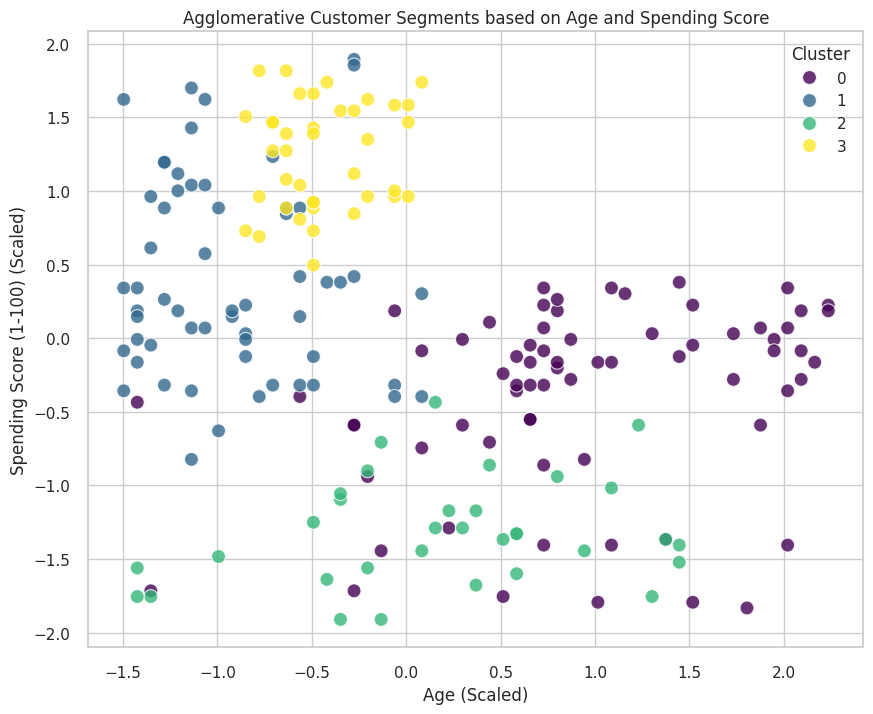

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='Agg_Cluster', data=mall_df_processed, palette='viridis', s=100, alpha=0.8)
plt.title('Agglomerative Customer Segments based on Age and Spending Score')
plt.xlabel('Age (Scaled)')
plt.ylabel('Spending Score (1-100) (Scaled)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### 5.8 Comparing K-Means and Agglomerative Clustering

We can now visually compare the cluster assignments from K-Means and Agglomerative Clustering. We can also summarize the characteristics of the Agglomerative clusters similar to what we did for K-Means to understand if they yield similar or different segmentations.

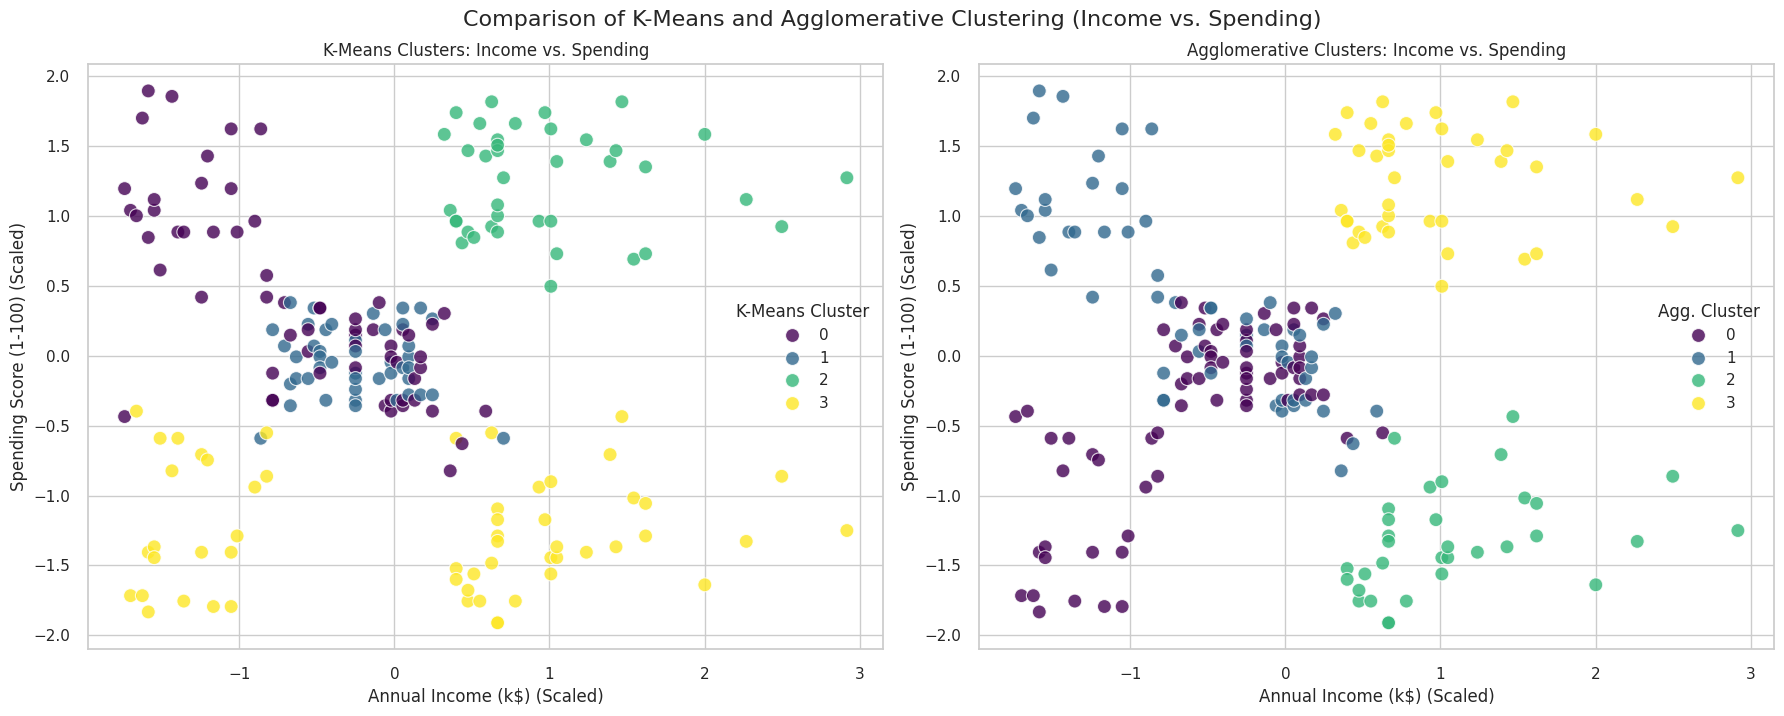

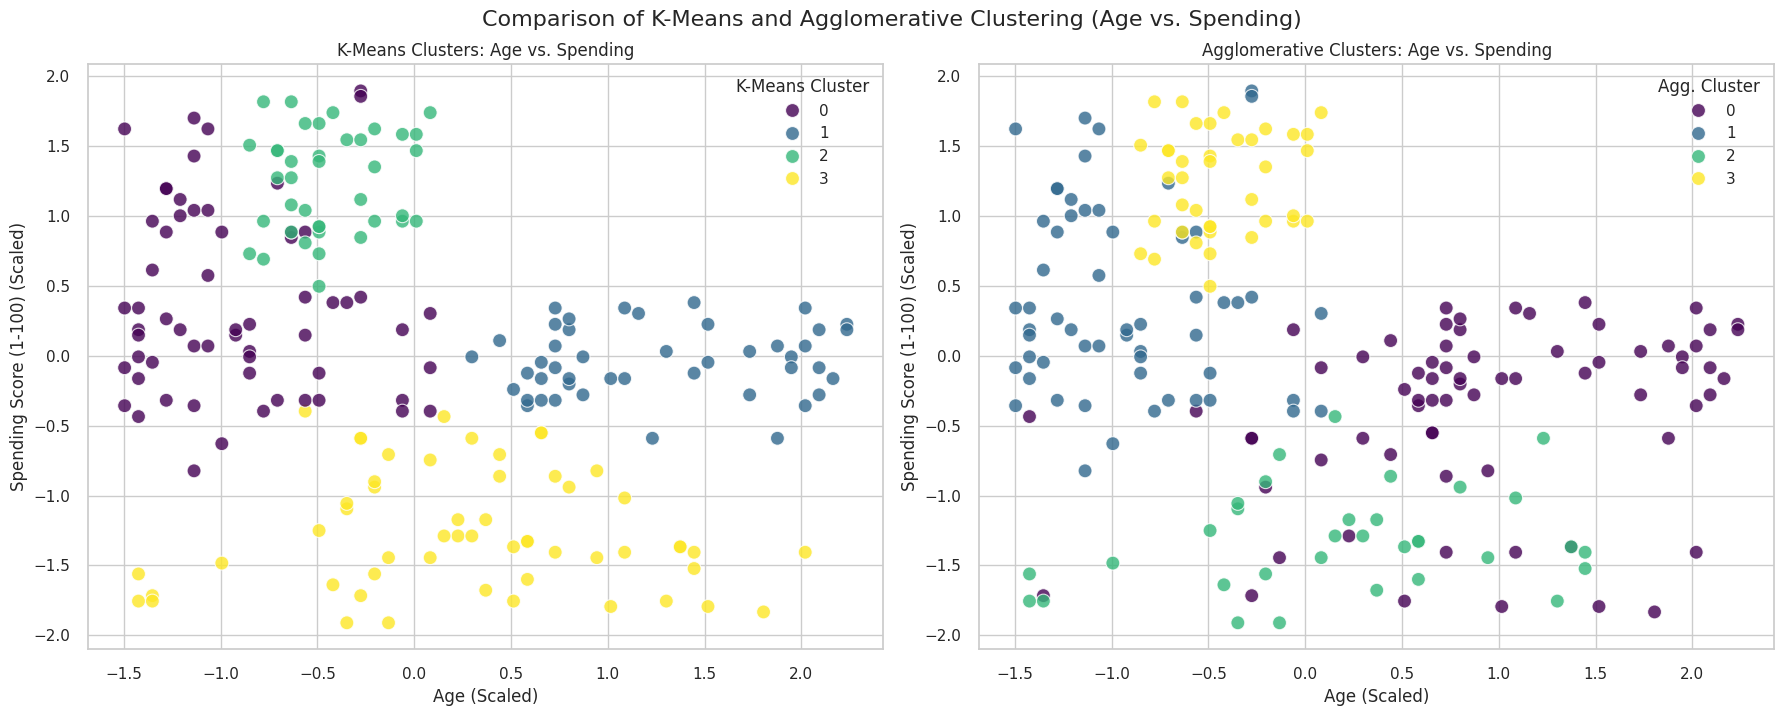

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# K-Means Plot
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=mall_df_processed, palette='viridis', s=100, alpha=0.8, ax=axes[0])
axes[0].set_title('K-Means Clusters: Income vs. Spending')
axes[0].set_xlabel('Annual Income (k$) (Scaled)')
axes[0].set_ylabel('Spending Score (1-100) (Scaled)')
axes[0].legend(title='K-Means Cluster')
axes[0].grid(True)

# Agglomerative Clustering Plot
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Agg_Cluster', data=mall_df_processed, palette='viridis', s=100, alpha=0.8, ax=axes[1])
axes[1].set_title('Agglomerative Clusters: Income vs. Spending')
axes[1].set_xlabel('Annual Income (k$) (Scaled)')
axes[1].set_ylabel('Spending Score (1-100) (Scaled)')
axes[1].legend(title='Agg. Cluster')
axes[1].grid(True)

plt.tight_layout()
plt.suptitle('Comparison of K-Means and Agglomerative Clustering (Income vs. Spending)', y=1.02, fontsize=16)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# K-Means Plot
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='Cluster', data=mall_df_processed, palette='viridis', s=100, alpha=0.8, ax=axes[0])
axes[0].set_title('K-Means Clusters: Age vs. Spending')
axes[0].set_xlabel('Age (Scaled)')
axes[0].set_ylabel('Spending Score (1-100) (Scaled)')
axes[0].legend(title='K-Means Cluster')
axes[0].grid(True)

# Agglomerative Clustering Plot
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='Agg_Cluster', data=mall_df_processed, palette='viridis', s=100, alpha=0.8, ax=axes[1])
axes[1].set_title('Agglomerative Clusters: Age vs. Spending')
axes[1].set_xlabel('Age (Scaled)')
axes[1].set_ylabel('Spending Score (1-100) (Scaled)')
axes[1].legend(title='Agg. Cluster')
axes[1].grid(True)

plt.tight_layout()
plt.suptitle('Comparison of K-Means and Agglomerative Clustering (Age vs. Spending)', y=1.02, fontsize=16)
plt.show()

### 5.9 Exercise: Further Exploration on Mall Customer Segmentation

**Objective:** Continue the exploration of clustering techniques on the 'Mall Customer Segmentation Data' to gain a deeper understanding of customer segments using various methods.

1.  **Agglomerative Clustering with Different Linkage Methods:**
    *   Apply Agglomerative Clustering to the processed `mall_df_processed` dataset using the optimal `n_clusters` (e.g., 4 or 5, as suggested by Elbow/Silhouette methods or the Dendogram) and each of the following `linkage` methods: 'ward', 'complete', 'average', 'single'.
    *   For each linkage method, visualize the clusters (e.g., using 'Annual Income' vs 'Spending Score') and calculate the Silhouette Score.
    *   **Discuss:** How do the different linkage methods affect the resulting customer segments? Which linkage method seems most appropriate for this dataset and why?

2.  **DBSCAN Application and Parameter Tuning:**
    *   Apply DBSCAN to the processed `mall_df_processed` dataset.
    *   Use the k-distance plot (as demonstrated earlier) to estimate an appropriate `eps` value for this dataset.
    *   Experiment with different `eps` and `min_samples` values.
    *   Visualize the resulting clusters and analyze the number of clusters found and noise points.
    *   **Discuss:** What insights does DBSCAN provide about the customer segments that K-Means or Agglomerative Clustering might miss? What are the advantages and disadvantages of using DBSCAN for customer segmentation in this context?

3.  **Comprehensive Comparison and Recommendation:**
    *   Summarize your findings from K-Means, Agglomerative Clustering (with different linkages), and DBSCAN on the Mall Customer dataset.
    *   Based on your analysis, which clustering algorithm and configuration would you recommend for segmenting these customers, and why? Consider interpretability, cluster shape, and handling of outliers.

# 6. API References

To better understand the parameters and attributes of the methods we are using, you can refer to the official documentation:

### Machine Learning (scikit-learn & yellowbrick)
*   [**KMeans**](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html): Partitioning method based on centroids.
*   [**AgglomerativeClustering**](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html): Hierarchical bottom-up clustering.
*   [**DBSCAN**](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html): Density-Based Spatial Clustering of Applications with Noise.
*   [**StandardScaler**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html): Standardization of features.
*   [**NearestNeighbors**](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html): Neighbor search implementation.
*   [**Yellowbrick SilhouetteVisualizer**](https://www.scikit-yb.org/en/latest/api/cluster/silhouette.html): Visualization of silhouette scores.

### Hierarchical Analysis
*   [**SciPy Cluster Hierarchy**](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html): Functions for hierarchical clustering and dendrogram generation.